<a href="https://colab.research.google.com/github/YogeshQA-Diwakar/Python-Data-Analysis-with-Gemini-AI/blob/main/Python_For_Data_Analysis_Using_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
try:
    # Take inputs from the user and convert them to floats
    num1 = float(input("Enter the first number: "))
    num2 = float(input("Enter the second number: "))

    # Perform calculations
    addition_result = num1 + num2
    multiplication_result = num1 * num2

    # Print the results in complete sentences
    print(f"The sum of {num1} and {num2} is {addition_result}.")
    print(f"The product of {num1} and {num2} is {multiplication_result}.")
except ValueError:
    print("Invalid input! Please make sure to enter valid numbers.")

Enter the first number: 47
Enter the second number: 67
The sum of 47.0 and 67.0 is 114.0.
The product of 47.0 and 67.0 is 3149.0.


In [7]:
def calculate_and_print():
    """
    Prompts the user for two space-separated numbers,
    calculates their sum and product, and prints the results.
    """
    try:
        # Take a single input line, split by spaces, and convert them to floats
        input_line = input("Enter two numbers separated by a space: ")
        num1, num2 = map(float, input_line.split())

        # Perform calculations
        addition_result = num1 + num2
        multiplication_result = num1 * num2

        # Print the results in complete sentences
        print(f"The sum of {num1} and {num2} is {addition_result}.")
        print(f"The product of {num1} and {num2} is {multiplication_result}.")
    except ValueError:
        print("Invalid input! Please make sure to enter exactly two valid numbers separated by a space.")

# Call the function to test it
calculate_and_print()

Enter two numbers separated by a space: 30 78
The sum of 30.0 and 78.0 is 108.0.
The product of 30.0 and 78.0 is 2340.0.


In [13]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('sales_q3.csv')

# Show the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Show the number of rows
print(f"\nNumber of rows: {len(df)}")

# Show the data type of each column
print("\nData types of each column:")
print(df.dtypes)

First 5 rows of the dataset:


,Region,Rep,Revenue,Quarter,Deal_Status
0,North,P. Iyer,40000,Q3,Closed
1,South,M. Khan,56000,Q1,Open
2,East,A. Rao,200000,Q3,Closed
3,West,R. Desai,66000,Q2,Lost
4,North,D. Kapoor,32000,Q2,Open



Number of rows: 214

Data types of each column:
Region         object
Rep            object
Revenue         int64
Quarter        object
Deal_Status    object
dtype: object


In [14]:
# 1. Total Revenue by Region, highest to lowest
print("=== Total Revenue by Region (Highest to Lowest) ===")
revenue_by_region = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False).reset_index()
display(revenue_by_region)

# 2. Top 5 Reps by Revenue, counting only 'Closed' deals
print("\n=== Top 5 Reps by Revenue (Closed Deals Only) ===")
closed_deals = df[df['Deal_Status'] == 'Closed']
top_5_reps = closed_deals.groupby('Rep')['Revenue'].sum().sort_values(ascending=False).head(5).reset_index()
display(top_5_reps)

# 3. Pivot table: rows Region, columns Quarter, values sum of Revenue
print("\n=== Pivot Table: Region vs Quarter (Sum of Revenue) ===")
pivot_table = df.pivot_table(values='Revenue', index='Region', columns='Quarter', aggfunc='sum', fill_value=0)
display(pivot_table)

=== Total Revenue by Region (Highest to Lowest) ===


,Region,Revenue
0,East,6292000
1,West,3007000
2,North,2994000
3,South,2894000



=== Top 5 Reps by Revenue (Closed Deals Only) ===


,Rep,Revenue
0,A. Rao,2629000
1,T. Singh,958000
2,M. Khan,679000
3,D. Kapoor,637000
4,J. Thomas,617000



=== Pivot Table: Region vs Quarter (Sum of Revenue) ===


Quarter,Q1,Q2,Q3
Region,,,
East,1742000,2017000,2533000
North,884000,678000,1432000
South,528000,502000,1864000
West,729000,913000,1365000


In [15]:
# Load the CSV into a DataFrame named 'raw'
raw = pd.read_csv('sales_q3.csv')

# Show the first 8 rows
print("=== First 8 Rows ===")
display(raw.head(8))

# Show column data types
print("\n=== Column Data Types ===")
print(raw.dtypes)

# Show descriptive statistics
print("\n=== Descriptive Statistics Summary ===")
display(raw.describe(include='all'))

=== First 8 Rows ===


,Region,Rep,Revenue,Quarter,Deal_Status
0,North,P. Iyer,40000,Q3,Closed
1,South,M. Khan,56000,Q1,Open
2,East,A. Rao,200000,Q3,Closed
3,West,R. Desai,66000,Q2,Lost
4,North,D. Kapoor,32000,Q2,Open
5,East,A. Rao,127000,Q3,Closed
6,South,J. Thomas,23000,Q2,Open
7,East,K. Nair,55000,Q3,Lost



=== Column Data Types ===
Region         object
Rep            object
Revenue         int64
Quarter        object
Deal_Status    object
dtype: object

=== Descriptive Statistics Summary ===


,Region,Rep,Revenue,Quarter,Deal_Status
count,214,214,214.000000,214,214
unique,4,12,NaN,3,3
top,East,A. Rao,NaN,Q3,Closed
freq,58,28,NaN,105,116
mean,NaN,NaN,70967.289720,NaN,NaN
std,NaN,NaN,43079.071911,NaN,NaN
min,NaN,NaN,18000.000000,NaN,NaN
25%,NaN,NaN,43250.000000,NaN,NaN
50%,NaN,NaN,60000.000000,NaN,NaN
75%,NaN,NaN,84000.000000,NaN,NaN


In [ ]:
import pandas as pd

# Load the sales raw dataset
raw_sales = pd.read_csv('/content/sales_raw.csv')

# Display the original columns and a sample to identify correct column names
print("Original Columns:", raw_sales.columns.tolist())
display(raw_sales.head(2))

In [19]:
import pandas as pd

# Ensure the dataset is loaded
raw_sales = pd.read_csv('sales_raw.csv')

# 1. Standardise 'reason' to title case and trim spaces (Only if the column exists)
reason_cols = [col for col in raw_sales.columns if col.lower() == 'reason']
if reason_cols:
    reason_col = reason_cols[0]
    raw_sales[reason_col] = raw_sales[reason_col].astype(str).str.strip().str.title()
else:
    print("Warning: 'reason' column not found in dataset. Skipping step 1.")

# 2. Mark blank regions as 'unmapped'
region_cols = [col for col in raw_sales.columns if col.lower() == 'region']
if region_cols:
    region_col = region_cols[0]
    raw_sales[region_col] = raw_sales[region_col].fillna('unmapped')
    raw_sales[region_col] = raw_sales[region_col].replace(r'^\s*$', 'unmapped', regex=True)

# 3. Convert revenue from text with commas and rupee symbols into numbers
revenue_cols = [col for col in raw_sales.columns if col.lower() == 'revenue']
if revenue_cols:
    revenue_col = revenue_cols[0]
    raw_sales[revenue_col] = raw_sales[revenue_col].astype(str).str.replace('₹', '', regex=False)
    raw_sales[revenue_col] = raw_sales[revenue_col].str.replace(',', '', regex=False)
    raw_sales[revenue_col] = pd.to_numeric(raw_sales[revenue_col].str.strip(), errors='coerce')

# 4. Flag the duplicate invoice IDs in a new column called 'is duplicate'
invoice_cols = [col for col in raw_sales.columns if 'invoice' in col.lower() or 'id' in col.lower()]
if invoice_cols:
    invoice_col = invoice_cols[0]
    raw_sales['is duplicate'] = raw_sales.duplicated(subset=[invoice_col], keep=False)

# Display the cleaned DataFrame summary and a preview
print("\nCleaned Data Preview:")
display(raw_sales.head(10))


Cleaned Data Preview:


,Invoice_ID,Region,Rep,Revenue,Quarter,Deal_Status,is duplicate
0,INV-1080,East,K. Nair,77400.0,Q3,Open,False
1,INV-1074,East,A. Rao,113700.0,Q3,Lost,False
2,INV-1201,south,J. Thomas,95000.0,Q3,Open,False
3,INV-1149,WEST,R. Desai,109800.0,Q3,Open,False
4,INV-1141,West,N. Shah,96700.0,Q3,Open,False
5,INV-1091,East,S. Mehta,66100.0,Q3,Lost,False
6,INV-1153,North,D. Kapoor,32100.0,Q3,Open,False
7,INV-1047,east,S. Mehta,37900.0,Q3,Lost,False
8,INV-1083,East,S. Mehta,66100.0,Q3,Closed,False
9,INV-1244,unmapped,R. Desai,16900.0,Q3,Closed,False


In [20]:
# 1. Row count
row_count = len(raw_sales)
print(f"Total Row Count: {row_count}")

# 2. Unique region values
region_col = [col for col in raw_sales.columns if col.lower() == 'region'][0]
unique_regions = raw_sales[region_col].unique()
print(f"Unique Regions: {unique_regions}")

# 3. Number of rows flagged as duplicates
duplicate_count = raw_sales['is duplicate'].sum()
print(f"Number of Rows Flagged as Duplicates: {duplicate_count}")

Total Row Count: 214
Unique Regions: ['East' 'south' 'WEST' 'West' 'North' 'east ' 'unmapped' 'South' 'north']
Number of Rows Flagged as Duplicates: 14


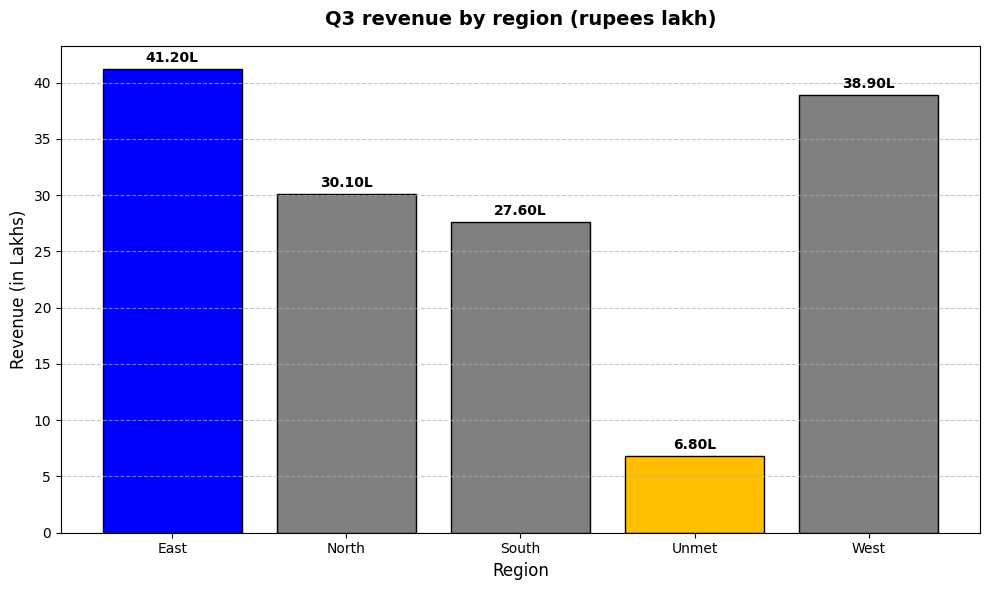

In [21]:
import matplotlib.pyplot as plt

# Standardise region names first (Title Case, trim whitespace, and map 'unmapped' to 'Unmet' as requested)
region_col = [col for col in raw_sales.columns if col.lower() == 'region'][0]
raw_sales[region_col] = raw_sales[region_col].astype(str).str.strip().str.title()
raw_sales[region_col] = raw_sales[region_col].replace({'Unmapped': 'Unmet'})

# Aggregate total revenue by region
revenue_by_region = raw_sales.groupby(region_col)['Revenue'].sum().reset_index()

# Convert revenue to lakhs (1 Lakh = 100,000 rupees)
revenue_by_region['Revenue_Lakhs'] = revenue_by_region['Revenue'] / 100000.0

# Define the color mapping
colors = []
for reg in revenue_by_region[region_col]:
    if reg == 'East':
        colors.append('blue')
    elif reg == 'Unmet':
        colors.append('#FFBF00') # Amber color hex
    else:
        colors.append('grey')

# Plotting the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(revenue_by_region[region_col], revenue_by_region['Revenue_Lakhs'], color=colors, edgecolor='black')

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}L',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customise chart elements
ax.set_title('Q3 revenue by region (rupees lakh)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Revenue (in Lakhs)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

In [22]:
# Identify correct column names from raw_sales
region_col = [col for col in raw_sales.columns if col.lower() == 'region'][0]
revenue_col = [col for col in raw_sales.columns if col.lower() == 'revenue'][0]

# Group by region and aggregate total revenue, average deal size, and deal count
summary_table = raw_sales.groupby(region_col).agg(
    total_revenue_lakh=(revenue_col, lambda x: x.sum() / 100000.0),
    average_deal_size=(revenue_col, 'mean'),
    deal_count=(revenue_col, 'count')
).reset_index()

# Rename columns for clarity
summary_table.columns = ['Region', 'Total Revenue (Lakh)', 'Average Deal Size', 'Deal Count']

# Sort by total revenue descending
summary_table = summary_table.sort_values(by='Total Revenue (Lakh)', ascending=False).reset_index(drop=True)

# Display the summary table
display(summary_table)

,Region,Total Revenue (Lakh),Average Deal Size,Deal Count
0,East,41.2,71034.482759,58
1,West,38.9,72037.037037,54
2,North,30.1,62708.333333,48
3,South,27.6,67317.073171,41
4,Unmet,6.8,68000.000000,10


In [23]:
# Save to clean_sales.xlsx with two sheets
with pd.ExcelWriter('clean_sales.xlsx') as writer:
    raw_sales.to_excel(writer, sheet_name='Data', index=False)
    summary_table.to_excel(writer, sheet_name='Summary', index=False)

print("Saved 'clean_sales.xlsx' successfully with sheets: 'Data' and 'Summary'.")

Saved 'clean_sales.xlsx' successfully with sheets: 'Data' and 'Summary'.
